# Neural Networks with Plain SGD — PyTorch Compact MLP on `dataset_stratified.csv`

This notebook evaluates a compact PyTorch multilayer perceptron (MLP) on the Covertype data using **plain SGD only**. It also trains a scikit-learn `MLPClassifier` with SGD only for the required implementation comparison.

Data split policy used in this version:

- `DATA_PATH` points to the sampled/stratified dataset used only for model development.
- The sampled/stratified dataset is split into **80% training** and **20% validation** with stratification.
- `DATA_PATH_TEST` points to the remaining/remainder dataset used only as the final held-out test set.
- The final test set is never sampled from `DATA_PATH`.

Implemented constraints and deliverables:

- PyTorch optimizer: `torch.optim.SGD` with **momentum = 0.0**, **Nesterov disabled**, and no adaptive optimizer.
- scikit-learn optimizer: `MLPClassifier(solver="sgd", momentum=0.0, nesterovs_momentum=False)`.
- Capacity scaling: shallow-wide versus deeper-narrower MLPs with approximately similar parameter counts.
- Hyperparameter exploration: three learning rates, three depth/width architectures, and four width values for the model-complexity curve.
- Required outputs: epoch learning curves, training-size learning curves, model-complexity curves, runtime table, confusion matrix, and per-class metrics.
- Metrics: accuracy, macro-F1, balanced accuracy, per-class precision/recall/F1.


> **Repository alignment:** This notebook is structured for the standalone `01-model-benchmarking-and-error-analysis` project root. Inputs are read from `data/raw/covertype/` or `data/processed/`; metrics, runtime tables, model-comparison artifacts, confusion matrices, and figures are written to the project-local `results/` and `figures/` folders.


In [1]:
# Project-local configuration, paths, and imports
import os
import sys
from pathlib import Path

MODULE_NAME = "01-model-benchmarking-and-error-analysis"
NOTEBOOK_SLUG = "07_pytorch_mlp_sgd"


def _find_project_root(start: str | Path | None = None) -> Path:
    """Find the 01-model-benchmarking-and-error-analysis project root."""
    start_path = Path(start or os.environ.get("MODEL_BENCHMARK_ROOT", Path.cwd())).resolve()
    for candidate in [start_path, *start_path.parents]:
        if candidate.name == MODULE_NAME and (candidate / "notebooks").exists():
            return candidate
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "src").exists()
            and (candidate / "scripts").exists()
        ):
            return candidate
    return start_path


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.data.project_paths import get_paths
except Exception as exc:
    raise ImportError(
        "Could not import src.data.project_paths. Run this notebook from inside "
        "01-model-benchmarking-and-error-analysis or set MODEL_BENCHMARK_ROOT."
    ) from exc

PATHS = get_paths(PROJECT_ROOT)

RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
DATASET_STRATIFIED_PATH = PATHS.dataset_stratified_path
DATASET_REMAINDER_PATH = PATHS.dataset_remainder_path

RESULTS_METRICS_DIR = PATHS.results_metrics_dir
RESULTS_RUNTIME_DIR = PATHS.results_runtime_dir
RESULTS_MODEL_COMPARISON_DIR = PATHS.results_model_comparison_dir
RESULTS_CONFUSION_MATRICES_DIR = PATHS.results_confusion_matrices_dir

FIG_EDA_DIR = PATHS.figures_eda_dir
FIG_LEARNING_CURVES_DIR = PATHS.figures_learning_curves_dir
FIG_MODEL_COMPLEXITY_DIR = PATHS.figures_model_complexity_dir
FIG_CONFUSION_MATRICES_DIR = PATHS.figures_confusion_matrices_dir
FIG_RUNTIME_DIR = PATHS.figures_runtime_dir

REPORTS_DIR = PATHS.reports_dir

# Backward-compatible aliases used by the original notebooks.
# New output writes below are routed to the specific category folders above.
OUT_DIR = RESULTS_METRICS_DIR
RESULTS_DIR = RESULTS_METRICS_DIR
FIG_DIR = FIG_EDA_DIR if NOTEBOOK_SLUG.startswith(("01_", "02_")) else FIG_MODEL_COMPLEXITY_DIR

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_METRICS_DIR,
    RESULTS_RUNTIME_DIR,
    RESULTS_MODEL_COMPARISON_DIR,
    RESULTS_CONFUSION_MATRICES_DIR,
    FIG_EDA_DIR,
    FIG_LEARNING_CURVES_DIR,
    FIG_MODEL_COMPLEXITY_DIR,
    FIG_CONFUSION_MATRICES_DIR,
    FIG_RUNTIME_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Input protocol:
# - Notebook 01 reads raw covtype.data and creates dataset_stratified.csv + dataset_remainder.csv.
# - Notebooks 02-08 read dataset_stratified.csv for train/validation.
# - Model notebooks also read dataset_remainder.csv for untouched final testing.
DATA_PATH_RAW = RAW_DATA_DIR / "covtype.data"
DATA_PATH = DATASET_STRATIFIED_PATH
DATA_PATH_TEST = DATASET_REMAINDER_PATH
TARGET_COL = "Cover_Type"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
if NOTEBOOK_SLUG not in {'02_eda_dataset_sampled', '01_eda_dataset_original'}:
    print("DATA_PATH_TEST:", DATA_PATH_TEST)
print("Processed data:", PROCESSED_DATA_DIR)
print("Results/metrics:", RESULTS_METRICS_DIR)
print("Results/runtime:", RESULTS_RUNTIME_DIR)
print("Results/model-comparison:", RESULTS_MODEL_COMPARISON_DIR)
print("Results/confusion-matrices:", RESULTS_CONFUSION_MATRICES_DIR)
print("Figures/EDA:", FIG_EDA_DIR)
print("Figures/learning-curves:", FIG_LEARNING_CURVES_DIR)
print("Figures/model-complexity-curves:", FIG_MODEL_COMPLEXITY_DIR)
print("Figures/confusion-matrices:", FIG_CONFUSION_MATRICES_DIR)

from pathlib import Path
import os
import sys
import platform
import random
import time
import json
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))


PROJECT_ROOT: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis
DATA_PATH: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
DATA_PATH_TEST: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_remainder.csv
Processed data: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed
Results/metrics: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/metrics
Results/runtime: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/runtime
Results/model-comparison: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/model-comparison
Results/confusion-matrices: /home/vision/Repos/ml-model-e

## 1. Load sampled/stratified train-validation data, load external test data, and scale features

In [2]:
for path_name, path_value in [("DATA_PATH", DATA_PATH), ("DATA_PATH_TEST", DATA_PATH_TEST)]:
    if not path_value.exists():
        raise FileNotFoundError(
            f"Could not find {path_name} at {path_value.resolve()}. "
            "Update the path variable above or place the expected CSV file at that location."
        )

df_source = pd.read_csv(DATA_PATH)
df_test_external = pd.read_csv(DATA_PATH_TEST)

for frame_name, frame in [
    ("sampled/stratified train-validation dataset", df_source),
    ("external remainder test dataset", df_test_external),
]:
    assert TARGET_COL in frame.columns, (
        f"Expected target column '{TARGET_COL}' in {frame_name}; found: {frame.columns.tolist()}"
    )

feature_cols = [col for col in df_source.columns if col != TARGET_COL]
required_test_cols = feature_cols + [TARGET_COL]
missing_test_cols = [col for col in required_test_cols if col not in df_test_external.columns]
if missing_test_cols:
    raise ValueError(f"DATA_PATH_TEST is missing required columns: {missing_test_cols}")

extra_test_cols = [col for col in df_test_external.columns if col not in df_source.columns]
if extra_test_cols:
    print(f"Warning: DATA_PATH_TEST has extra columns that will be ignored: {extra_test_cols}")

# Enforce identical feature order across train/validation and test.
df_test_external = df_test_external[required_test_cols].copy()

X_source_df = df_source[feature_cols].copy()
y_source_raw = df_source[TARGET_COL].copy()

X_test_df = df_test_external[feature_cols].copy()
y_test_raw = df_test_external[TARGET_COL].copy()

# Fit labels on the union of development and external test labels to preserve stable class IDs.
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_source_raw, y_test_raw], ignore_index=True))
class_labels = label_encoder.classes_
classes = np.arange(len(class_labels))
class_names = [f"Cover_Type_{c}" for c in class_labels]

# Required split: 80% of sampled/stratified DATA_PATH for training,
# 20% of sampled/stratified DATA_PATH for validation.
# DATA_PATH_TEST is kept as the untouched final test set.
X_train_df, X_val_df, y_train_raw, y_val_raw = train_test_split(
    X_source_df,
    y_source_raw,
    test_size=0.20,
    stratify=y_source_raw,
    random_state=SEED,
)

y_train = label_encoder.transform(y_train_raw).astype(np.int64)
y_val = label_encoder.transform(y_val_raw).astype(np.int64)
y_test = label_encoder.transform(y_test_raw).astype(np.int64)

if len(np.setdiff1d(classes, np.unique(y_train))) > 0:
    raise ValueError(
        "At least one class is absent from the training split. "
        "Use a stratified source dataset that contains all classes."
    )

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "source": ["DATA_PATH", "DATA_PATH", "DATA_PATH_TEST"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "percent_of_sampled_stratified_DATA_PATH": [
        len(X_train) / len(X_source_df),
        len(X_val) / len(X_source_df),
        np.nan,
    ],
    "used_for": ["model fitting", "model selection / early stopping", "final held-out evaluation"],
})
split_summary.to_csv(RESULTS_METRICS_DIR / "split_summary.csv", index=False)
display(split_summary)

class_balance_tables = []
for split_name, labels in [
    ("sampled_stratified_source", y_source_raw),
    ("train", y_train_raw),
    ("validation", y_val_raw),
    ("test_external_remainder", y_test_raw),
]:
    counts = pd.Series(labels).value_counts().sort_index()
    table = counts.rename_axis(TARGET_COL).reset_index(name="count")
    table["split"] = split_name
    table["percent_within_split"] = 100 * table["count"] / table["count"].sum()
    class_balance_tables.append(table)

class_balance = pd.concat(class_balance_tables, ignore_index=True)
class_balance = class_balance[["split", TARGET_COL, "count", "percent_within_split"]]
class_balance.to_csv(RESULTS_METRICS_DIR / "class_balance.csv", index=False)
display(class_balance)

print(f"Sampled/stratified source rows: {df_source.shape[0]:,}")
print(f"External remainder test rows: {df_test_external.shape[0]:,}")
print(f"Features: {len(feature_cols):,}; classes: {len(class_labels)}")
print(f"Train: {X_train.shape}; validation: {X_val.shape}; test: {X_test.shape}")

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
).astype(np.float32)
class_weights_torch = torch.tensor(class_weights_np)

weights_table = pd.DataFrame({
    "encoded_class": classes,
    "cover_type": class_labels,
    "balanced_weight": class_weights_np,
})
weights_table.to_csv(RESULTS_METRICS_DIR / "class_weights.csv", index=False)
display(weights_table)

X_val_t = torch.tensor(X_val)
y_val_t = torch.tensor(y_val)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)


,split,source,rows,percent_of_sampled_stratified_DATA_PATH,used_for
0,train,DATA_PATH,16000,0.8,model fitting
1,validation,DATA_PATH,4000,0.2,model selection / early stopping
2,test,DATA_PATH_TEST,561012,NaN,final held-out evaluation


,split,Cover_Type,count,percent_within_split
0,sampled_stratified_source,1,7292,36.460000
1,sampled_stratified_source,2,9752,48.760000
2,sampled_stratified_source,3,1231,6.155000
3,sampled_stratified_source,4,94,0.470000
4,sampled_stratified_source,5,327,1.635000
5,sampled_stratified_source,6,598,2.990000
6,sampled_stratified_source,7,706,3.530000
7,train,1,5834,36.462500
8,train,2,7801,48.756250
9,train,3,985,6.156250


Sampled/stratified source rows: 20,000
External remainder test rows: 561,012
Features: 54; classes: 7
Train: (16000, 54); validation: (4000, 54); test: (561012, 54)


,encoded_class,cover_type,balanced_weight
0,0,1,0.391792
1,1,2,0.293003
2,2,3,2.320522
3,3,4,30.476191
4,4,5,8.724100
5,5,6,4.781829
6,6,7,4.045512


## 2. Define the compact MLP and plain-SGD training loop

In [3]:
class CompactMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim):
        super().__init__()
        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers.extend([nn.Linear(prev, width), nn.ReLU()])
            prev = width
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def metrics_from_predictions(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    }


def evaluate_model(model, X_t, y_t, criterion):
    model.eval()
    with torch.no_grad():
        logits = model(X_t)
        loss = criterion(logits, y_t).item()
        pred = logits.argmax(1).cpu().numpy()
    metrics = metrics_from_predictions(y_t.cpu().numpy(), pred)
    metrics['loss'] = loss
    return metrics


def predict_pytorch(model, X_np):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X_np, dtype=torch.float32)).argmax(1).cpu().numpy()


def train_pytorch_mlp(
    X_train_np, y_train_np, hidden_layers, lr, max_epochs=45, patience=7,
    batch_size=512, weight_decay=1e-4, class_weights=None, track_train_metrics=False, seed=SEED
):
    torch.manual_seed(seed)
    X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_np, dtype=torch.long)
    n = len(y_train_np)

    if class_weights is None:
        class_weights = torch.tensor(compute_class_weight(class_weight='balanced', classes=classes, y=y_train_np).astype(np.float32))

    model = CompactMLP(X_train_np.shape[1], list(hidden_layers), len(class_labels))
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    # Plain SGD only: no momentum, no Nesterov, no adaptive optimizer.
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0, nesterov=False, weight_decay=weight_decay)

    best_val_macro_f1 = -np.inf
    best_epoch = 0
    best_state = None
    no_improve = 0
    history = []
    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        perm = torch.randperm(n)
        train_loss_sum = 0.0
        for start_idx in range(0, n, batch_size):
            idx = perm[start_idx:start_idx + batch_size]
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(X_train_t[idx]), y_train_t[idx])
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * len(idx)

        val_metrics = evaluate_model(model, X_val_t, y_val_t, criterion)
        row = {
            'epoch': epoch,
            'train_loss': train_loss_sum / n,
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_balanced_accuracy': val_metrics['balanced_accuracy'],
        }
        if track_train_metrics:
            train_metrics = evaluate_model(model, X_train_t, y_train_t, criterion)
            row.update({
                'train_accuracy': train_metrics['accuracy'],
                'train_macro_f1': train_metrics['macro_f1'],
                'train_balanced_accuracy': train_metrics['balanced_accuracy'],
            })
        history.append(row)

        if val_metrics['macro_f1'] > best_val_macro_f1 + 1e-4:
            best_val_macro_f1 = val_metrics['macro_f1']
            best_epoch = epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    fit_time = time.perf_counter() - start
    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df['epoch'].eq(best_epoch)].iloc[0].to_dict()
    return {
        'model': model,
        'history': history_df,
        'best_epoch': best_epoch,
        'best_val_macro_f1': best_val_macro_f1,
        'best_row': best_row,
        'fit_time_sec': fit_time,
        'param_count': count_parameters(model),
    }

## 3. Hyperparameter sweeps: learning rate, depth/width, and width complexity

,learning_rate,architecture,param_count,best_epoch,fit_time_sec,best_val_accuracy,best_val_macro_f1,best_val_balanced_accuracy
2,0.10,"(64, 64)",8135,26,1.624273,0.6470,0.554536,0.706070
1,0.05,"(64, 64)",8135,16,1.100487,0.5985,0.497115,0.634795
0,0.01,"(64, 64)",8135,42,1.656736,0.5245,0.446605,0.640386


,architecture_name,hidden_layers,param_count,best_epoch,fit_time_sec,best_val_accuracy,best_val_macro_f1,best_val_balanced_accuracy
1,"balanced_[64,64]","(64, 64)",8135,26,1.594945,0.64700,0.554536,0.706070
0,wide_shallow_[128],"(128,)",7943,22,1.261117,0.63275,0.521260,0.650229
2,"deep_narrow_[52,52,52]","(52, 52, 52)",8743,11,1.004927,0.63550,0.504202,0.592627


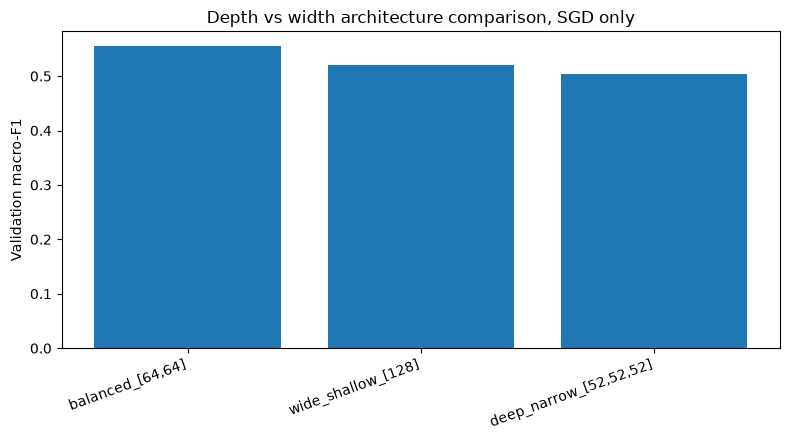

,width,hidden_layers,param_count,best_epoch,fit_time_sec,best_val_accuracy,best_val_macro_f1,best_val_balanced_accuracy
0,16,"(16, 16)",1271,29,1.388781,0.63050,0.524003,0.709332
1,32,"(32, 32)",3047,12,0.814168,0.59875,0.513484,0.685077
2,64,"(64, 64)",8135,26,1.591650,0.64700,0.554536,0.706070
3,128,"(128, 128)",24455,27,2.161880,0.65325,0.553491,0.705298


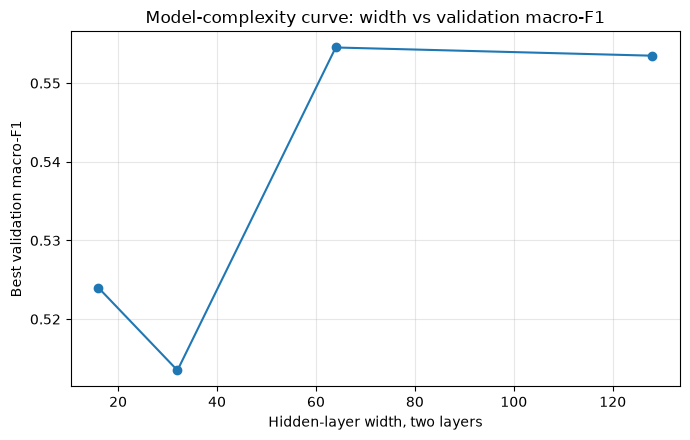

Selected LR: 0.1; selected architecture: balanced_[64,64] = (64, 64)


In [4]:
LR_VALUES = [0.01, 0.05, 0.10]
BASE_ARCH = (64, 64)
BATCH_SIZE = 512
MAX_EPOCHS = 45
PATIENCE = 7
WEIGHT_DECAY = 1e-4

# Learning-rate sweep
lr_rows = []
for lr in LR_VALUES:
    run = train_pytorch_mlp(
        X_train, y_train, hidden_layers=BASE_ARCH, lr=lr,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
        weight_decay=WEIGHT_DECAY, class_weights=class_weights_torch,
    )
    lr_rows.append({
        'learning_rate': lr,
        'architecture': str(BASE_ARCH),
        'param_count': run['param_count'],
        'best_epoch': run['best_epoch'],
        'fit_time_sec': run['fit_time_sec'],
        'best_val_accuracy': run['best_row']['val_accuracy'],
        'best_val_macro_f1': run['best_val_macro_f1'],
        'best_val_balanced_accuracy': run['best_row']['val_balanced_accuracy'],
    })

lr_sweep = pd.DataFrame(lr_rows).sort_values('best_val_macro_f1', ascending=False)
lr_sweep.to_csv(RESULTS_MODEL_COMPARISON_DIR / 'lr_sweep.csv', index=False)
best_lr = float(lr_sweep.iloc[0]['learning_rate'])
display(lr_sweep)

# Similar-parameter depth-vs-width architecture comparison
ARCHITECTURES = {
    'wide_shallow_[128]': (128,),
    'balanced_[64,64]': (64, 64),
    'deep_narrow_[52,52,52]': (52, 52, 52),
}
arch_rows = []
for name, arch in ARCHITECTURES.items():
    run = train_pytorch_mlp(
        X_train, y_train, hidden_layers=arch, lr=best_lr,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
        weight_decay=WEIGHT_DECAY, class_weights=class_weights_torch,
    )
    arch_rows.append({
        'architecture_name': name,
        'hidden_layers': str(arch),
        'param_count': run['param_count'],
        'best_epoch': run['best_epoch'],
        'fit_time_sec': run['fit_time_sec'],
        'best_val_accuracy': run['best_row']['val_accuracy'],
        'best_val_macro_f1': run['best_val_macro_f1'],
        'best_val_balanced_accuracy': run['best_row']['val_balanced_accuracy'],
    })
architecture_sweep = pd.DataFrame(arch_rows).sort_values('best_val_macro_f1', ascending=False)
architecture_sweep.to_csv(RESULTS_MODEL_COMPARISON_DIR / 'architecture_sweep.csv', index=False)
display(architecture_sweep)
selected_architecture_name = architecture_sweep.iloc[0]['architecture_name']
selected_architecture = ARCHITECTURES[selected_architecture_name]

plt.figure(figsize=(8, 4.5))
plt.bar(architecture_sweep['architecture_name'], architecture_sweep['best_val_macro_f1'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('Validation macro-F1')
plt.title('Depth vs width architecture comparison, SGD only')
plt.tight_layout()
plt.savefig(FIG_MODEL_COMPLEXITY_DIR / '01_pytorch_architecture_depth_width_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Model-complexity curve: scalar width sweep
width_rows = []
for width in [16, 32, 64, 128]:
    arch = (width, width)
    run = train_pytorch_mlp(
        X_train, y_train, hidden_layers=arch, lr=best_lr,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
        weight_decay=WEIGHT_DECAY, class_weights=class_weights_torch,
    )
    width_rows.append({
        'width': width,
        'hidden_layers': str(arch),
        'param_count': run['param_count'],
        'best_epoch': run['best_epoch'],
        'fit_time_sec': run['fit_time_sec'],
        'best_val_accuracy': run['best_row']['val_accuracy'],
        'best_val_macro_f1': run['best_val_macro_f1'],
        'best_val_balanced_accuracy': run['best_row']['val_balanced_accuracy'],
    })
width_sweep = pd.DataFrame(width_rows)
width_sweep.to_csv(RESULTS_MODEL_COMPARISON_DIR / 'model_complexity_width_sweep.csv', index=False)
display(width_sweep)

plt.figure(figsize=(7, 4.5))
plt.plot(width_sweep['width'], width_sweep['best_val_macro_f1'], marker='o')
plt.xlabel('Hidden-layer width, two layers')
plt.ylabel('Best validation macro-F1')
plt.title('Model-complexity curve: width vs validation macro-F1')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_MODEL_COMPLEXITY_DIR / '02_pytorch_model_complexity_width_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Selected LR: {best_lr}; selected architecture: {selected_architecture_name} = {selected_architecture}')

## 4. Final selected model, learning curves, test evaluation, sklearn comparison, and runtime

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy,train_accuracy,train_macro_f1,train_balanced_accuracy
31,32,0.595403,0.629701,0.64200,0.533050,0.736984,0.650312,0.558480,0.764199
32,33,0.590542,0.782808,0.64750,0.513865,0.698127,0.655125,0.529556,0.733759
33,34,0.597542,0.643448,0.61775,0.507887,0.717182,0.626750,0.531899,0.750051
34,35,0.584427,0.652314,0.61250,0.516659,0.722675,0.623875,0.540537,0.759660
35,36,0.574872,0.633849,0.63600,0.531054,0.729035,0.643563,0.551888,0.760606


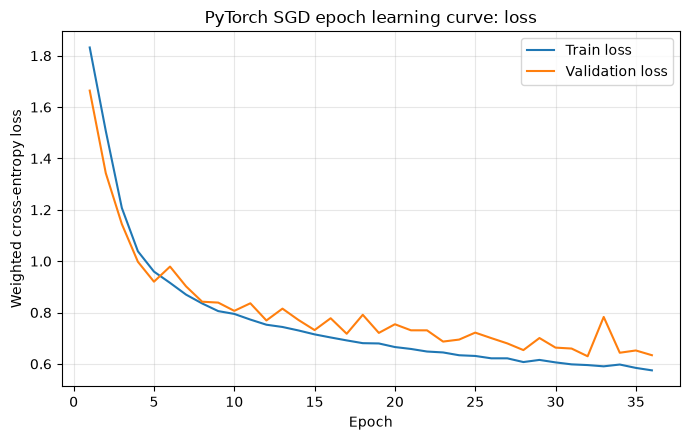

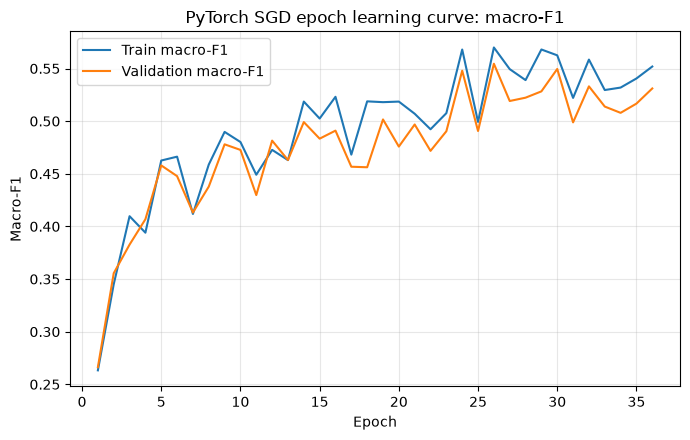

,train_fraction,train_size,best_epoch,fit_time_sec,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_balanced_accuracy,val_balanced_accuracy
0,0.10,1600,45,0.541019,0.579375,0.55450,0.502261,0.461491,0.647485,0.599251
1,0.25,4000,28,0.620117,0.592000,0.57150,0.527606,0.503089,0.687952,0.637458
2,0.50,8000,17,0.660719,0.601375,0.60475,0.515892,0.500816,0.694494,0.665684
3,1.00,16000,26,1.597619,0.647062,0.64700,0.569986,0.554536,0.727191,0.706070


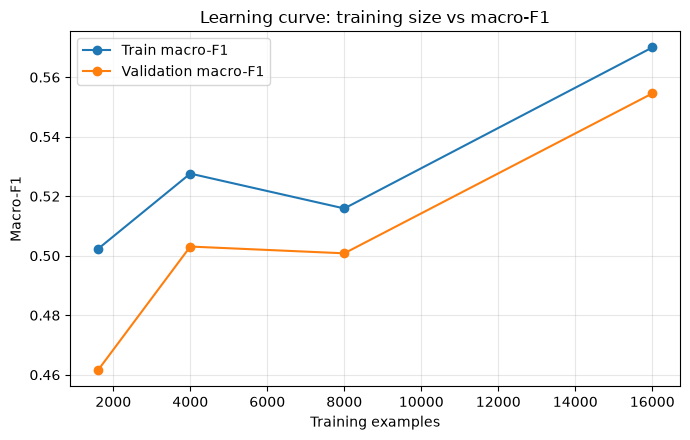

,model,accuracy,macro_f1,balanced_accuracy
0,PyTorch MLP SGD only,0.640099,0.55264,0.701977


,precision,recall,f1-score,support
Cover_Type_1,0.695849,0.694893,0.695371,204548.000000
Cover_Type_2,0.794858,0.568319,0.662764,273549.000000
Cover_Type_3,0.638997,0.733598,0.683037,34523.000000
Cover_Type_4,0.432364,0.644553,0.517554,2653.000000
Cover_Type_5,0.134451,0.822169,0.231109,9166.000000
Cover_Type_6,0.380079,0.590733,0.462551,16769.000000
Cover_Type_7,0.480103,0.859574,0.616095,19804.000000
accuracy,0.640099,0.640099,0.640099,0.640099
macro avg,0.508100,0.701977,0.552640,561012.000000
weighted avg,0.713154,0.640099,0.660529,561012.000000


,Cover_Type_1,Cover_Type_2,Cover_Type_3,Cover_Type_4,Cover_Type_5,Cover_Type_6,Cover_Type_7
Cover_Type_1,142139,38463,450,0,6629,507,16360
Cover_Type_2,59450,155463,6773,51,40622,9116,2074
Cover_Type_3,0,318,25326,1851,932,6096,0
Cover_Type_4,0,0,688,1710,0,255,0
Cover_Type_5,66,1084,297,0,7536,183,0
Cover_Type_6,0,170,6100,343,250,9906,0
Cover_Type_7,2612,88,0,0,81,0,17023


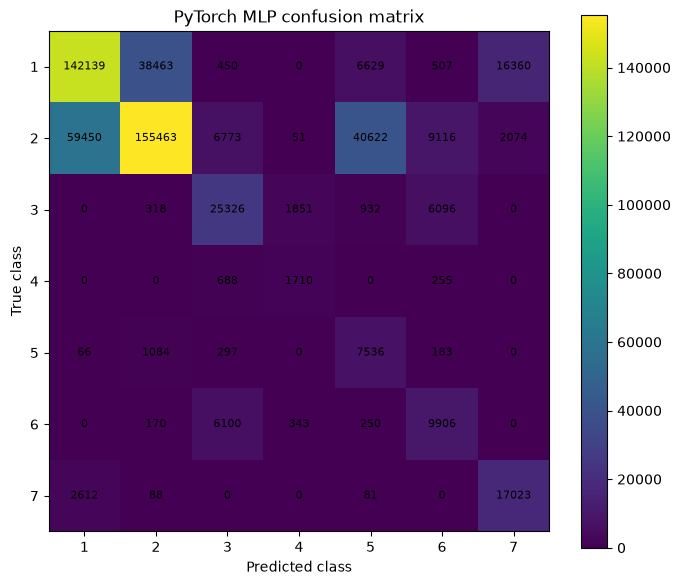

,model,accuracy,macro_f1,balanced_accuracy
0,scikit-learn MLPClassifier SGD only,0.626543,0.531539,0.718662


,precision,recall,f1-score,support
Cover_Type_1,0.702953,0.680574,0.691582,204548.000000
Cover_Type_2,0.790496,0.558565,0.654594,273549.000000
Cover_Type_3,0.648870,0.623816,0.636096,34523.000000
Cover_Type_4,0.308045,0.811157,0.446519,2653.000000
Cover_Type_5,0.121182,0.836679,0.211702,9166.000000
Cover_Type_6,0.381619,0.646789,0.480018,16769.000000
Cover_Type_7,0.457359,0.873056,0.600264,19804.000000
accuracy,0.626543,0.626543,0.626543,0.626543
macro avg,0.487218,0.718662,0.531539,561012.000000
weighted avg,0.712664,0.626543,0.651586,561012.000000


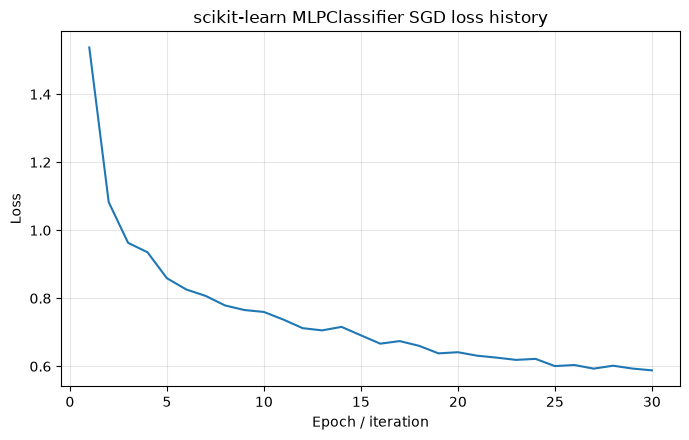

,model,fit_time_sec,predict_time_sec,epochs_run,best_epoch_or_score,architecture,param_count,learning_rate,batch_size,regularization
0,PyTorch MLP SGD only,2.349221,0.216678,36,26.000000,"(64, 64)",8135.0,0.1,512,L2 weight_decay=0.0001; early stopping on vali...
1,scikit-learn MLPClassifier SGD only,3.157330,0.805227,30,0.708607,"(64, 64)",NaN,0.1,512,L2 alpha=0.0001; sklearn early stopping on int...


,model,accuracy,macro_f1,balanced_accuracy,fit_time_sec,predict_time_sec,epochs_run
0,PyTorch MLP SGD only,0.640099,0.552640,0.701977,2.349221,0.216678,36
1,scikit-learn MLPClassifier SGD only,0.626543,0.531539,0.718662,3.157330,0.805227,30


{
  "train_validation_source_path": "/home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv",
  "external_test_source_path": "/home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_remainder.csv",
  "train_validation_source_rows": 20000,
  "external_test_rows": 561012,
  "train_rows": 16000,
  "validation_rows": 4000,
  "test_rows": 561012,
  "features": 54,
  "classes": 7,
  "selected_architecture_name": "balanced_[64,64]",
  "selected_architecture": [
    64,
    64
  ],
  "selected_learning_rate": 0.1,
  "batch_size": 512,
  "weight_decay": 0.0001,
  "pytorch": {
    "accuracy": 0.6400986075164168,
    "macro_f1": 0.5526402660451925,
    "balanced_accuracy": 0.7019769459556571,
    "fit_time_sec": 2.3492211469856557,
    "predict_time_sec": 0.21667823000461794,
    "epochs_run": 36,
    "best_epoch": 26,
    "param_count": 8135
  },
  "skle

In [5]:
# Final selected PyTorch run with full epoch train/validation curves
selected_run = train_pytorch_mlp(
    X_train, y_train, hidden_layers=selected_architecture, lr=best_lr,
    max_epochs=70, patience=10, batch_size=BATCH_SIZE,
    weight_decay=WEIGHT_DECAY, class_weights=class_weights_torch,
    track_train_metrics=True,
)
selected_model = selected_run['model']
pytorch_history = selected_run['history']
pytorch_history.to_csv(RESULTS_MODEL_COMPARISON_DIR / 'pytorch_selected_epoch_history.csv', index=False)
display(pytorch_history.tail())

plt.figure(figsize=(7, 4.5))
plt.plot(pytorch_history['epoch'], pytorch_history['train_loss'], label='Train loss')
plt.plot(pytorch_history['epoch'], pytorch_history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Weighted cross-entropy loss')
plt.title('PyTorch SGD epoch learning curve: loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / '01_pytorch_epoch_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(pytorch_history['epoch'], pytorch_history['train_macro_f1'], label='Train macro-F1')
plt.plot(pytorch_history['epoch'], pytorch_history['val_macro_f1'], label='Validation macro-F1')
plt.xlabel('Epoch')
plt.ylabel('Macro-F1')
plt.title('PyTorch SGD epoch learning curve: macro-F1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / '02_pytorch_epoch_macro_f1_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Training-size learning curve with four stratified sizes
learning_rows = []
for frac in [0.10, 0.25, 0.50, 1.00]:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=frac, stratify=y_train, random_state=SEED)
    else:
        X_sub, y_sub = X_train, y_train
    subset_weights = torch.tensor(compute_class_weight(class_weight='balanced', classes=classes, y=y_sub).astype(np.float32))
    run = train_pytorch_mlp(
        X_sub, y_sub, hidden_layers=selected_architecture, lr=best_lr,
        max_epochs=45, patience=7, batch_size=BATCH_SIZE,
        weight_decay=WEIGHT_DECAY, class_weights=subset_weights,
        track_train_metrics=False,
    )
    train_pred = predict_pytorch(run['model'], X_sub)
    val_pred = predict_pytorch(run['model'], X_val)
    train_metrics = metrics_from_predictions(y_sub, train_pred)
    val_metrics = metrics_from_predictions(y_val, val_pred)
    learning_rows.append({
        'train_fraction': frac,
        'train_size': len(y_sub),
        'best_epoch': run['best_epoch'],
        'fit_time_sec': run['fit_time_sec'],
        'train_accuracy': train_metrics['accuracy'],
        'val_accuracy': val_metrics['accuracy'],
        'train_macro_f1': train_metrics['macro_f1'],
        'val_macro_f1': val_metrics['macro_f1'],
        'train_balanced_accuracy': train_metrics['balanced_accuracy'],
        'val_balanced_accuracy': val_metrics['balanced_accuracy'],
    })
learning_curve = pd.DataFrame(learning_rows)
learning_curve.to_csv(RESULTS_MODEL_COMPARISON_DIR / 'learning_curve.csv', index=False)
display(learning_curve)

plt.figure(figsize=(7, 4.5))
plt.plot(learning_curve['train_size'], learning_curve['train_macro_f1'], marker='o', label='Train macro-F1')
plt.plot(learning_curve['train_size'], learning_curve['val_macro_f1'], marker='o', label='Validation macro-F1')
plt.xlabel('Training examples')
plt.ylabel('Macro-F1')
plt.title('Learning curve: training size vs macro-F1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / '03_pytorch_training_size_learning_curve_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Final PyTorch test evaluation
predict_start = time.perf_counter()
pytorch_test_pred = predict_pytorch(selected_model, X_test)
pytorch_predict_time = time.perf_counter() - predict_start
pytorch_test_metrics = metrics_from_predictions(y_test, pytorch_test_pred)
pytorch_metrics_df = pd.DataFrame([{'model': 'PyTorch MLP SGD only', **pytorch_test_metrics}])
pytorch_metrics_df.to_csv(RESULTS_METRICS_DIR / 'pytorch_test_metrics.csv', index=False)
pytorch_metrics_df.to_csv(RESULTS_METRICS_DIR / 'pytorch_test_metrics.csv', index=False)
display(pytorch_metrics_df)

pytorch_report = pd.DataFrame(classification_report(
    y_test, pytorch_test_pred, labels=classes, target_names=class_names, output_dict=True, zero_division=0
)).T
pytorch_report.to_csv(RESULTS_METRICS_DIR / 'classification_report_pytorch.csv')
display(pytorch_report)

pytorch_cm = confusion_matrix(y_test, pytorch_test_pred, labels=classes)
pytorch_cm_df = pd.DataFrame(pytorch_cm, index=class_names, columns=class_names)
pytorch_cm_df.to_csv(RESULTS_CONFUSION_MATRICES_DIR / 'confusion_matrix_pytorch.csv')
display(pytorch_cm_df)

plt.figure(figsize=(7, 6))
plt.imshow(pytorch_cm, interpolation='nearest')
plt.title('PyTorch MLP confusion matrix')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.xticks(range(len(class_names)), class_labels)
plt.yticks(range(len(class_names)), class_labels)
plt.colorbar()
for i in range(pytorch_cm.shape[0]):
    for j in range(pytorch_cm.shape[1]):
        plt.text(j, i, str(pytorch_cm[i, j]), ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_CONFUSION_MATRICES_DIR / '04_pytorch_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# scikit-learn MLPClassifier comparison under SGD-only constraints
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=selected_architecture,
    activation='relu',
    solver='sgd',
    alpha=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    learning_rate='constant',
    learning_rate_init=best_lr,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.20,
    n_iter_no_change=7,
    tol=1e-4,
    momentum=0.0,
    nesterovs_momentum=False,
    random_state=SEED,
    verbose=False,
)
sk_sample_weights = class_weights_np[y_train]
sk_fit_start = time.perf_counter()
sklearn_mlp.fit(X_train, y_train, sample_weight=sk_sample_weights)
sk_fit_time = time.perf_counter() - sk_fit_start
sk_predict_start = time.perf_counter()
sklearn_test_pred = sklearn_mlp.predict(X_test)
sk_predict_time = time.perf_counter() - sk_predict_start
sklearn_test_metrics = metrics_from_predictions(y_test, sklearn_test_pred)
sklearn_metrics_df = pd.DataFrame([{'model': 'scikit-learn MLPClassifier SGD only', **sklearn_test_metrics}])
display(sklearn_metrics_df)

sklearn_history = pd.DataFrame({'epoch': np.arange(1, len(sklearn_mlp.loss_curve_) + 1), 'train_loss': sklearn_mlp.loss_curve_})
if hasattr(sklearn_mlp, 'validation_scores_'):
    sklearn_history['internal_validation_accuracy'] = sklearn_mlp.validation_scores_
sklearn_history.to_csv(RESULTS_MODEL_COMPARISON_DIR / 'sklearn_epoch_history.csv', index=False)

sklearn_report = pd.DataFrame(classification_report(
    y_test, sklearn_test_pred, labels=classes, target_names=class_names, output_dict=True, zero_division=0
)).T
sklearn_report.to_csv(RESULTS_METRICS_DIR / 'classification_report_sklearn.csv')
display(sklearn_report)

sklearn_cm = confusion_matrix(y_test, sklearn_test_pred, labels=classes)
pd.DataFrame(sklearn_cm, index=class_names, columns=class_names).to_csv(RESULTS_CONFUSION_MATRICES_DIR / 'confusion_matrix_sklearn.csv')

plt.figure(figsize=(7, 4.5))
plt.plot(sklearn_history['epoch'], sklearn_history['train_loss'], label='scikit-learn train loss')
plt.xlabel('Epoch / iteration')
plt.ylabel('Loss')
plt.title('scikit-learn MLPClassifier SGD loss history')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / '05_pytorch_sklearn_epoch_history.png', dpi=150, bbox_inches='tight')
plt.show()

runtime_table = pd.DataFrame([
    {
        'model': 'PyTorch MLP SGD only',
        'fit_time_sec': selected_run['fit_time_sec'],
        'predict_time_sec': pytorch_predict_time,
        'epochs_run': int(pytorch_history['epoch'].max()),
        'best_epoch_or_score': selected_run['best_epoch'],
        'architecture': str(selected_architecture),
        'param_count': selected_run['param_count'],
        'learning_rate': best_lr,
        'batch_size': BATCH_SIZE,
        'regularization': f'L2 weight_decay={WEIGHT_DECAY}; early stopping on validation macro-F1',
    },
    {
        'model': 'scikit-learn MLPClassifier SGD only',
        'fit_time_sec': sk_fit_time,
        'predict_time_sec': sk_predict_time,
        'epochs_run': int(sklearn_mlp.n_iter_),
        'best_epoch_or_score': getattr(sklearn_mlp, 'best_validation_score_', np.nan),
        'architecture': str(selected_architecture),
        'param_count': np.nan,
        'learning_rate': best_lr,
        'batch_size': BATCH_SIZE,
        'regularization': f'L2 alpha={WEIGHT_DECAY}; sklearn early stopping on internal validation accuracy',
    },
])
runtime_table.to_csv(RESULTS_RUNTIME_DIR / 'runtime_table.csv', index=False)
runtime_table.to_csv(RESULTS_RUNTIME_DIR / 'runtime_table.csv', index=False)
display(runtime_table)

final_comparison = pd.concat([pytorch_metrics_df, sklearn_metrics_df], ignore_index=True)
final_comparison['fit_time_sec'] = runtime_table['fit_time_sec'].values
final_comparison['predict_time_sec'] = runtime_table['predict_time_sec'].values
final_comparison['epochs_run'] = runtime_table['epochs_run'].values
final_comparison.to_csv(RESULTS_MODEL_COMPARISON_DIR / 'final_sklearn_pytorch_comparison.csv', index=False)
final_comparison.to_csv(RESULTS_MODEL_COMPARISON_DIR / 'final_sklearn_pytorch_comparison.csv', index=False)
display(final_comparison)

summary = {
    "train_validation_source_path": str(DATA_PATH),
    "external_test_source_path": str(DATA_PATH_TEST),
    "train_validation_source_rows": int(df_source.shape[0]),
    "external_test_rows": int(df_test_external.shape[0]),
    "train_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "features": int(len(feature_cols)),
    "classes": int(len(class_labels)),
    "selected_architecture_name": selected_architecture_name,
    "selected_architecture": list(selected_architecture),
    "selected_learning_rate": best_lr,
    "batch_size": BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "pytorch": {
        **pytorch_test_metrics,
        "fit_time_sec": selected_run["fit_time_sec"],
        "predict_time_sec": pytorch_predict_time,
        "epochs_run": int(pytorch_history["epoch"].max()),
        "best_epoch": int(selected_run["best_epoch"]),
        "param_count": int(selected_run["param_count"]),
    },
    "sklearn": {
        **sklearn_test_metrics,
        "fit_time_sec": sk_fit_time,
        "predict_time_sec": sk_predict_time,
        "epochs_run": int(sklearn_mlp.n_iter_),
    },
    "hardware_note": f"CPU={platform.processor() or platform.machine()}, cores visible={os.cpu_count()}, torch threads={torch.get_num_threads()}",
}
with open(RESULTS_METRICS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))